# Project 3 - Learning an MPC Expert with a CBF Safety Filter

This project connects three ideas in one small pipeline:

1. an MPC expert computes good end-effector velocities,
2. a small NumPy neural network imitates those velocities,
3. a CBF-QP safety filter corrects the learned velocity when safety requires it.

The goal is not to build a deep learning system. The goal is to see how an MPC policy can become training data, and how a safety layer can sit between a learned controller and the plant.

## 1. Project idea: MPC expert -> learned policy -> CBF safety filter

At each time step the architecture is

$$
    p_k \longrightarrow v_{\mathrm{MPC}}(p_k)
$$

for expert data generation,

$$
    (p_k, \mathrm{scenario}) \longrightarrow v_{\mathrm{NN}}(p_k)
$$

for imitation learning, and finally

$$
    v_{\mathrm{safe},k}
    = \arg\min_v \|v - v_{\mathrm{NN},k}\|^2
$$

for the safety-filtered controller.

## 2. Simplified end-effector model and visual replay note

The MPC, learning, and CBF filter operate on the end-effector point model

$$
    p_{k+1} = p_k + T_s v_k,
    \qquad p_k \in \mathbb{R}^2, \quad v_k \in \mathbb{R}^2.
$$

The planar arm is a visual replay layer: each end-effector point \(p_k\) is mapped to a feasible arm configuration \(q_k\). The arm is what we plot and animate, but it is not the model optimized by the MPC in this project.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "project3_core.py").exists():
    candidate = PROJECT_DIR / "projects" / "project_3_learning_safety_filter"
    if candidate.exists():
        PROJECT_DIR = candidate

sys.path.insert(0, str(PROJECT_DIR))

import project3_core as core
import project3_visuals as visuals

ASSET_DIR = PROJECT_DIR / "assets"
OUTPUT_DIR = Path("outputs/project_3_learning_safety_filter")

RETRAIN_POLICY = False
REGENERATE_EXPERT_DATA = False
CREATE_ANIMATIONS = False

## 3. Scenario definition

The default scenario has one rectangular workspace, one circular keep-out zone, one start, and one goal.

The obstacle safety function is

$$
    h(p) = \|p - p_{\mathrm{obs}}\|^2 - r_{\mathrm{safe}}^2.
$$

The safe set is \(h(p) \ge 0\).

In [2]:
scenario = core.default_scenario()

for key in ["Ts", "N", "p_start", "p_goal", "p_obs", "r_safe", "p_min", "p_max", "v_min", "v_max"]:
    print(f"{key}: {scenario[key]}")
print("h(p_start):", core.safety_function(scenario["p_start"], scenario))

Ts: 0.1
N: 12
p_start: [-0.92 -0.42]
p_goal: [0.92 0.42]
p_obs: [0.02 0.02]
r_safe: 0.31
p_min: [-1.05 -0.75]
p_max: [1.05 0.75]
v_min: [-1. -1.]
v_max: [1. 1.]
h(p_start): 0.9811000000000002


## 4. MPC expert formulation

For a current point \(p_0\), the expert solves

$$
\begin{aligned}
\min_{v_0,\ldots,v_{N-1}}\quad
& \sum_{i=0}^{N-1}
    \|p_i - p_{\mathrm{goal}}\|_Q^2
    + \|v_i\|_R^2
    + \|p_N - p_{\mathrm{goal}}\|_P^2 \\
\text{s.t.}\quad
& p_{i+1} = p_i + T_s v_i, \\
& p_{\min} \le p_i \le p_{\max}, \\
& \|p_i - p_{\mathrm{obs}}\|^2 \ge r_{\mathrm{safe}}^2, \\
& v_{\min} \le v_i \le v_{\max}.
\end{aligned}
$$

The expert applies only the first velocity \(v_{\mathrm{MPC}} = v_0^\star\), then replans at the next step.

In [3]:
# A single transparent expert call. Dataset generation below uses the same helper.
solve_mpc = core.build_mpc_expert_solver(scenario)
v_mpc_start, mpc_status = solve_mpc(scenario["p_start"])
print("v_MPC at the start:", v_mpc_start)
print("solver status:", mpc_status)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

v_MPC at the start: [0.99999983 0.99999891]
solver status: Solve_Succeeded


## 5. Dataset and imitation learning idea

The imitation dataset has rows

$$
    (p, \mathrm{scenario}) \mapsto v_{\mathrm{MPC}}.
$$

The policy input features include the current point, the goal-relative vector, the obstacle-relative vector, the obstacle radius, and the current safety margin. The output is the learned end-effector velocity \(v_{\mathrm{NN}} \in \mathbb{R}^2\).

In [4]:
if REGENERATE_EXPERT_DATA:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    dataset = core.generate_expert_dataset(scenario, n_samples=120, seed=scenario["seed"])
    core.save_dataset(OUTPUT_DIR / "expert_dataset_small.npz", dataset)
    print("Regenerated MPC expert data in", OUTPUT_DIR)
else:
    dataset = core.load_dataset(ASSET_DIR / "expert_dataset_small.npz")
    print("Loaded committed MPC expert data from", ASSET_DIR)

print("points:", dataset["p"].shape)
print("expert velocities:", dataset["v_mpc"].shape)
print("policy features:", dataset["features"].shape)

Loaded committed MPC expert data from /workspace/projects/project_3_learning_safety_filter/assets
points: (120, 2)
expert velocities: (120, 2)
policy features: (120, 8)


## 6. Load pretrained policy or optionally retrain

The policy is a small two-hidden-layer NumPy MLP with tanh activations. It is trained with mean squared imitation loss

$$
    \frac{1}{M}\sum_j \|\pi_\theta(p_j, \mathrm{scenario}) - v_{\mathrm{MPC},j}\|^2.
$$

The learning happens inside `core.train_policy(...)`: the network predicts $v_{\mathrm{NN}}$, compares it with the stored MPC expert input $v_{\mathrm{MPC}}$, backpropagates the imitation error, and updates the weights with Adam.

Default path: load the committed pretrained weights and training history. Set `RETRAIN_POLICY = True` only when you explicitly want to train a new policy and write the result to `outputs/...`.

Loaded pretrained policy and training history


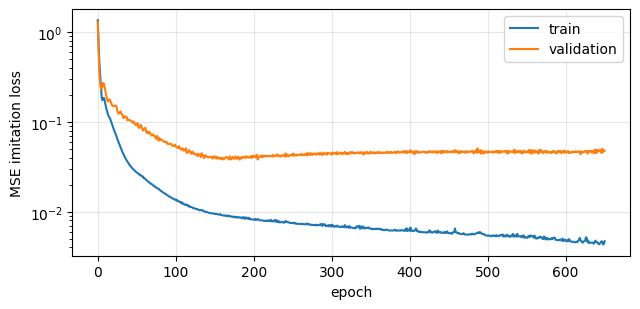

In [5]:
if RETRAIN_POLICY:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # This is the imitation-learning step:
    # train a small NumPy network to reproduce the first MPC input.
    policy, history_rows, snapshots = core.train_policy(
        dataset,
        scenario,
        epochs=650,
        learning_rate=3e-3,
        batch_size=32,
        seed=scenario["seed"],
    )
    core.save_policy(OUTPUT_DIR / "policy_trained.npz", policy)
    core.save_training_history(OUTPUT_DIR / "training_history.csv", history_rows)
    core.save_training_snapshots(OUTPUT_DIR / "training_rollout_snapshots.npz", snapshots)
    history = core.load_training_history(OUTPUT_DIR / "training_history.csv")
    print("Saved retrained policy products in", OUTPUT_DIR)
else:
    policy = core.load_policy(ASSET_DIR / "policy_pretrained.npz")
    history = core.load_training_history(ASSET_DIR / "training_history_pretrained.csv")
    snapshots = core.load_training_snapshots(ASSET_DIR / "training_rollout_snapshots.npz")
    print("Loaded pretrained policy and training history")

visuals.plot_training_history(history)
plt.show()

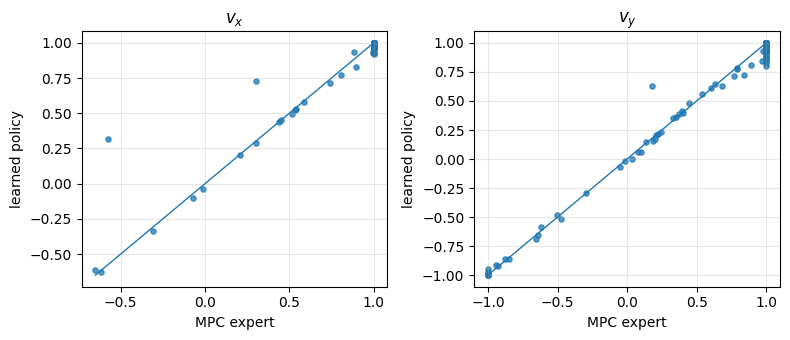

In [6]:
visuals.plot_policy_scatter_or_error(dataset, policy, scenario, core)
plt.show()

## 7. CBF-QP safety filter derivation

For the point model, the time derivative of the safety function along velocity \(v\) is

$$
    \dot h(p) = 2(p - p_{\mathrm{obs}})^T v.
$$

A simple CBF condition is

$$
    2(p - p_{\mathrm{obs}})^T v \ge -\alpha h(p).
$$

The safety filter solves the visible two-dimensional QP

$$
\begin{aligned}
    v_{\mathrm{safe}}
    = \arg\min_v \quad & \|v - v_{\mathrm{NN}}\|^2 \\
    \text{s.t.}\quad
    & 2(p - p_{\mathrm{obs}})^T v \ge -\alpha h(p), \\
    & v_{\min} \le v \le v_{\max}.
\end{aligned}
$$

The implementation returns the safety margin before and after the step, the intervention norm \(\|v_{\mathrm{safe}} - v_{\mathrm{NN}}\|\), the QP status, and whether the CBF constraint is active.

In [7]:
p_test = scenario["p_start"]
v_nn_test = core.policy_velocity(policy, p_test, scenario)
v_safe_test, cbf_info = core.cbf_safety_filter(p_test, v_nn_test, scenario)

print("v_NN:", v_nn_test)
print("v_safe:", v_safe_test)
print(cbf_info)

v_NN: [1.         0.95198997]
v_safe: [0.67034065 0.79768133]
{'h_before': 0.9811000000000002, 'h_after': 0.7957365210066977, 'intervention_norm': 0.3639868668270983, 'qp_status': 'Optimization terminated successfully', 'qp_success': True, 'active_cbf': True, 'cbf_margin': 4.440892098500626e-16}


## 8. Closed-loop evaluation

We compare three controllers:

- MPC expert,
- learned policy only,
- learned policy plus the CBF-QP safety filter.

The evaluation metrics include final goal error, minimum safety margin \(\min_k h(p_k)\), and CBF intervention statistics.

In [8]:
expert_rollout = core.simulate_mpc_expert(scenario, steps=55)
learned_rollout = core.simulate_learned_policy(policy, scenario, steps=55, use_cbf=False)
safe_rollout = core.simulate_learned_policy(policy, scenario, steps=55, use_cbf=True)

rows = [
    core.rollout_metrics("MPC expert", expert_rollout),
    core.rollout_metrics("learned policy", learned_rollout),
    core.rollout_metrics("learned + CBF-QP", safe_rollout),
]
for row in rows:
    print(row)
trajectory_gap = np.linalg.norm(learned_rollout["p"] - safe_rollout["p"], axis=1)
print("max learned-vs-CBF trajectory separation:", float(np.max(trajectory_gap)))
print("mean learned-vs-CBF trajectory separation:", float(np.mean(trajectory_gap)))
print("max CBF intervention norm:", float(np.max(safe_rollout["intervention"])))


{'controller': 'MPC expert', 'goal_error': 4.7476532474121135e-06, 'min_h': 0.02909709846988072}
{'controller': 'learned policy', 'goal_error': 0.010043548255002043, 'min_h': 0.020955759473070087, 'mean_filter_intervention': 0.0, 'active_cbf_steps': 0}
{'controller': 'learned + CBF-QP', 'goal_error': 0.010043548256363215, 'min_h': 0.09011571428461666, 'mean_filter_intervention': 0.08733246082612303, 'active_cbf_steps': 14}
max learned-vs-CBF trajectory separation: 0.4129761822782202
mean learned-vs-CBF trajectory separation: 0.11512808958952658
max CBF intervention norm: 0.551786585147525


## 9. Planar arm comparison plots

The traces below are not mass-point plots. Each spatial panel replays the end-effector trajectory through a feasible two-link planar arm configuration.

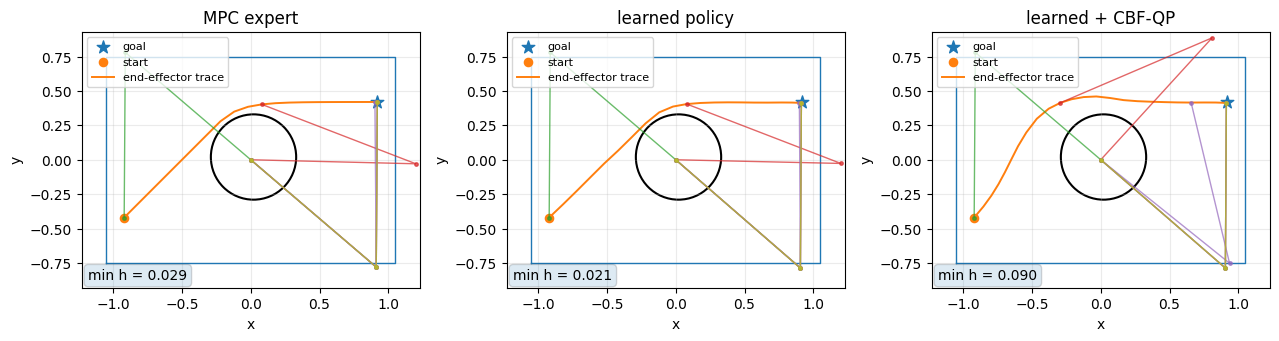

In [9]:
rollouts = {
    "MPC expert": expert_rollout,
    "learned policy": learned_rollout,
    "learned + CBF-QP": safe_rollout,
}
visuals.plot_arm_rollout_comparison(rollouts, scenario, stride=10)
plt.show()

## 10. Optional animations

Animations are disabled by default to keep the notebook lightweight. If `CREATE_ANIMATIONS = True`, GIF files are written to `outputs/project_3_learning_safety_filter/`.

In [10]:
if CREATE_ANIMATIONS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    visuals.animate_arm_safe_vs_unsafe(
        learned_rollout,
        safe_rollout,
        scenario,
        output_path=OUTPUT_DIR / "safe_vs_unsafe_arm.gif",
        fps=12,
    )
    visuals.animate_training_arm_snapshots(
        snapshots,
        scenario,
        output_path=OUTPUT_DIR / "training_arm_snapshots.gif",
        fps=10,
    )
    print("Saved animations in", OUTPUT_DIR)
else:
    print("Animations are disabled. Set CREATE_ANIMATIONS = True to save GIFs.")

Animations are disabled. Set CREATE_ANIMATIONS = True to save GIFs.


## 11. Interpretation questions

1. Where does the learned MPC surrogate copy the MPC expert well, and where does it still make errors?
2. Why can a small imitation model reach the goal in this simple scenario, even though it is not solving an optimization problem online?
3. When the CBF-QP intervenes, which constraint is it protecting?
4. What behavior would you expect if the obstacle moved but the policy input did not include the obstacle-relative vector?
5. What advantages and disadvantages does this architecture have compared with running MPC directly at every time step?